In [7]:
import ase.units as units
from ase.build import molecule
from ase.calculators.tip3p import TIP3P
from ase.constraints import FixBondLengths
from ase.io.trajectory import Trajectory
from ase.md import Langevin

import matplotlib.pyplot as plt 
from ase.visualize.plot import plot_atoms 

## Equilibrating with NVT

In [9]:
water_molecules = molecule('H2O') # creating water molecule
density = 0.9982  # denisty of water in g/cm^3 at 20°C
box_length = ((water_molecules.get_masses().sum() / units.mol) / (density * 1e-24)) ** (
    1 / 3
)  # box length in Å
water_molecules.set_cell((box_length, box_length, box_length))
water_molecules.center()
# Repeat the water molecule we just created to end up with a PBC cell
water_molecules *= (3, 3, 3)
water_molecules.set_pbc(True)

water_molecules.constraints = FixBondLengths(
    [(3 * i + j, 3 * i + (j + 1) % 3) for i in range(3**3) for j in [0, 1, 2]]
)
# RATTLE-type constraints on O-H1, O-H2, H1-H2.
tag = 'tip3p_27mol_equil'
water_molecules.calc = TIP3P(rc=4.5)  # set the calculator to be the TIP3P force field

def print_stats(a):
    volume = a.get_volume()
    temp = a.get_temperature()
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    etot = ekin + epot
    print(
        f'Current Volume: {volume:.3f} '
        f'Current Temperature: {temp:.3f} K '
        f'Current total energy: {etot:.3f} eV '
    )

# Equillibrate in a small box first.
md = Langevin(
    water_molecules,
    1 * units.fs,
    temperature_K=300,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)

print('Now starting equilibration of small box')
print_stats(water_molecules)
print_per = 10
for i in range(print_per):
    md.run(40)  #prints every 40 steps
    print_stats(water_molecules)


# Repeat box and equilibrate further.

tag = 'tip3p_216mol_equil'
water_molecules.set_constraint()  # repeat not compatible with FixBondLengths currently.
water_molecules *= (2, 2, 2)
water_molecules.constraints = FixBondLengths(
    [
        (3 * i + j, 3 * i + (j + 1) % 3)
        for i in range(len(water_molecules) // 3)
        for j in [0, 1, 2]
    ]
)
water_molecules.calc = TIP3P(rc=7.0)

md = Langevin(
    water_molecules,
    2 * units.fs,
    temperature_K=300,  # 20 °C
    friction=0.01,
    logfile=tag + '.log',
)

traj = Trajectory(tag + '.traj', 'w', water_molecules)
md.attach(traj.write, interval=1)
print('Now starting equilibration of repeated box')
print_stats(water_molecules)
for i in range(print_per):
    md.run(20)  # please use 4000 to better equilibrate
    print_stats(water_molecules)

 # please use 2000 to better equilibrate

/home/fh22600/miniforge3/envs/cp2k_env/lib/python3.14t/site-packages/ase/md/langevin.py:102: FutureWarning: The implementation of `fixcm=True` in `Langevin` does not strictly sample the correct NVT distributions. The deviations are typically small for large systems but can be more pronounced for small systems. Use `fixcm=False` together with `ase.constraints.FixCom`. `fixcm` is deprecated since ASE 3.28.0 and will be removed in a future release.
  warnings.warn(msg, FutureWarning)


Now starting equilibration of small box
Current Volume: 809.151 Current Temperature: 1198.481 K Current total energy: 5.698 eV 
Current Volume: 809.151 Current Temperature: 1160.367 K Current total energy: 5.123 eV 
Current Volume: 809.151 Current Temperature: 1401.246 K Current total energy: 4.807 eV 
Current Volume: 809.151 Current Temperature: 1141.798 K Current total energy: 4.334 eV 
Current Volume: 809.151 Current Temperature: 1299.252 K Current total energy: 3.740 eV 
Current Volume: 809.151 Current Temperature: 1204.889 K Current total energy: 3.246 eV 
Current Volume: 809.151 Current Temperature: 1386.216 K Current total energy: 2.954 eV 
Current Volume: 809.151 Current Temperature: 1030.154 K Current total energy: 2.182 eV 
Current Volume: 809.151 Current Temperature: 1180.353 K Current total energy: 2.041 eV 
Current Volume: 809.151 Current Temperature: 1069.671 K Current total energy: 1.423 eV 
Now starting equilibration of repeated box
Current Volume: 6473.208 Current Temp

Water MD with TIP3P, equilibrating with NVE

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# choose one of the following implementations of EMT:
# included in ase
# from ase.calculators.emt import EMT
# faster performance

from ase.calculators.tip4p import TIP3P
from ase import units
from ase.cluster.cubic import FaceCenteredCubic as ClusterFCC
from ase.io.trajectory import Trajectory
from ase.lattice.cubic import FaceCenteredCubic as LatticeFCC
from ase.md.langevin import Langevin  # for later NPT simulations
from ase.md.velocitydistribution import (
    MaxwellBoltzmannDistribution,
    Stationary,
    ZeroRotation,
)
from ase.md.verlet import VelocityVerlet
from ase.optimize import QuasiNewton
from ase.visualize.plot import plot_atoms
from ase.io import read, write

NameError: name 'view' is not defined

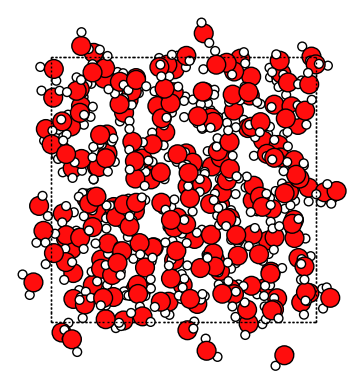

In [ ]:
#pre equilibrated water 
#water_molecules = read('tip3p_equilibrated.traj')
fig, ax = plt.subplots()
plot_atoms(water_molecules, ax)
#view(water_molecules)
ax.set_axis_off()

Equilibrating with NPT

In [ ]:
from ase.calculators.cp2k import CP2K
import os 
from ase.md.nptberendsen import NPTBerendsen
os.environ['OMP_NUM_THREADS'] = '8'

print(os.environ['OMP_NUM_THREADS'])

water_molecules.calc = CP2K(inp='''&FORCE_EVAL
  &DFT
    &QS
      METHOD xTB
      &XTB
        CHECK_ATOMIC_CHARGES F
        COULOMB_INTERACTION T
        DO_EWALD T
      &END XTB
    &END QS
    &SCF
      SCF_GUESS RESTART
      EPS_SCF 1.0E-6
      &OT
        MINIMIZER DIIS
        ENERGY_GAP 0.1
        PRECONDITIONER FULL_SINGLE_INVERSE
      &END OT
    &END SCF
  &END DFT
&END FORCE_EVAL
''')

# Set the initial velocities corresponding to T=300K from Maxwell Boltzmann
# Distribution
MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


timestep_fs = 2 # to capture hydrogen bonding interactions, time step short 
#dyn = VelocityVerlet(water_molecules, timestep_fs * units.fs)  #  fs time step.
dyn = NPTBerendsen(water_molecules, timestep=2 * units.fs, temperature_K=300,
                   taut=100 * units.fs, pressure_au=1.01325 * units.bar,
                   taup=1000 * units.fs, compressibility_au=4.57e-5 / units.bar)

def printenergy(a):
    """
    Function to print the thermodynamical properties i.e potential energy,
    kinetic energy and total energy
    """
    epot = a.get_potential_energy()
    ekin = a.get_kinetic_energy()
    temp = a.get_temperature()
    print(
        f'Energy per atom: Epot ={epot:6.3f}eV  Ekin = {ekin:.3f}eV '
        f'(T={temp:.3f}K) Etot = {epot + ekin:.3f}eV'
    )

# Now run the dynamics
print('running a NPT simulation of equilibrated water ')
print(water_molecules)
# init lists to for energy vs time data
time_ps, epot, ekin = [], [], []
mdind = 0
steps_per_block = 1

traj = Trajectory('xtb_test'+ '.traj', 'w', water_molecules)

# write to trajectory every 
dyn.attach(traj.write, interval=1) 

# each iteration up to 200 is one block of 2 steps 
for i in range(200):

    
    dyn.run(steps_per_block)
    mdind += steps_per_block
    printenergy(water_molecules)

    # save the energies of the current MD step
    time_ps.append(mdind * timestep_fs / 1000.0)
    epot.append(water_molecules.get_potential_energy())
    ekin.append(water_molecules.get_kinetic_energy())

etot = np.array(epot) + np.array(ekin)

traj.close()
# Plot energies vs time
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(time_ps, epot, label='Potential energy')
ax.plot(time_ps, ekin, label='Kinetic energy')
ax.plot(time_ps, etot, label='Total energy')
ax.set_xlabel('Time (ps)')
ax.set_ylabel('Energy (eV)')
ax.legend(loc='best')
ax.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()


8


/tmp/ipykernel_26444/1559991083.py:33: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(water_molecules, temperature_K=300)


running a NPT simulation of equilibrated water 
Atoms(symbols='H432O216', pbc=True, cell=[18.63687879989203, 18.63687879989203, 18.63687879989203], momenta=..., constraint=<ase.constraints.fix_bond_lengths.FixBondLengths object at 0x270bc117550>, calculator=CP2K(...))


/home/fh22600/miniforge3/envs/cp2k_env/lib/python3.14t/site-packages/ase/calculators/cp2k.py:323: UserWarning: ASE may stall when passing large structures to MPI versions of CP2K. Consider using `set_pos_file=True`.
  warn('ASE may stall when passing large structures'


Energy per atom: Epot =-33991.863eV  Ekin = 17.328eV (T=310.319K) Etot = -33974.535eV
Energy per atom: Epot =-33992.306eV  Ekin = 17.742eV (T=317.719K) Etot = -33974.565eV
Energy per atom: Epot =-33992.947eV  Ekin = 18.342eV (T=328.474K) Etot = -33974.605eV
Energy per atom: Epot =-33993.736eV  Ekin = 19.075eV (T=341.606K) Etot = -33974.660eV
Energy per atom: Epot =-33994.614eV  Ekin = 19.879eV (T=356.003K) Etot = -33974.735eV
Energy per atom: Epot =-33995.522eV  Ekin = 20.690eV (T=370.525K) Etot = -33974.831eV
Energy per atom: Epot =-33996.400eV  Ekin = 21.450eV (T=384.134K) Etot = -33974.950eV
Energy per atom: Epot =-33997.200eV  Ekin = 22.110eV (T=395.951K) Etot = -33975.090eV


In [13]:
from ase.visualize import view
print(len(water_molecules))

view(water_molecules)

648


<Popen: returncode: None args: ['/home/fh22600/miniforge3/envs/cp2k_env/bin/...>

Water box has no kinetic energy, has reached lowest energy structure

## Visualise trajectories


In [ ]:
# visualise xtb_test.traj 
# ase gui xtb_test.traj 

(20,)

1. Get equilibrated and thermolised box using berendsten at npt, print out / save box dimensions and water coordinates once trajectories are random enough. (1 fs timestep), total duration ~ 1000 fs to get totally random configuration, and write every 100 frames.
2. Get final frame to get equilibrated and thermolised water box.
3. Switch to velocity verlet to run NVE simulation, basically running equilibrium MD of water. (2 fs timestep)
4. For equilibrium MD, write to trajectory every 5 frames.

### Generating training data from equilibrium MD runs

1. trajectories will be saved as extended .xyz files
2. Select a starting water box configuration
3. In a for loop,  generate random velocities with maxwell distribution and get 100 frames

OR 

1. Select last 10 MD frames
2. From each frame, run MD with randomly generated velocities and get 100 frames.
